# EMTA andmete analüüs

##### faili nimi . ipynb e interactive python notebook

## Ettevalmistus

In [56]:
import pandas as pd #csv faili lugemiseks nt
import duckdb #sql kasutamiseks
import matplotlib.pyplot as plt # tabelite tegemiseks
import seaborn as sns # tabelite tegemiseks 

from typing import Callable

## Andmetega tutvumine

In [57]:
data_raw_this_year = pd.read_csv("tasutud_maksud_kaesolev_aasta.csv", nrows=5)
data_raw_this_year 

# mida üks rida tähendab? 
# nrows - mitu rida näed tabelist, tabel algab alati 0
# andmeid saab sisse lugeda nii panda kui duckdb

,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,Riiklikud maksud I kv,Riiklikud maksud II kv,Riiklikud maksud III kv,...,Tööjõumaksud III kv,Tööjõumaksud IV kv,Käive I kv,Käive II kv,Käive III kv,Käive IV kv,Töötajate arv I kv,Töötajate arv II kv,Töötajate arv III kv,Töötajate arv IV kv
0,10.04.2026,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,1723565,2038192.0,2141341.0,...,1213643.0,1131417.0,34309154,30413704.0,23282177.0,21724706.0,254.0,243.0,244.0,240.0
1,10.04.2026,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2026,1561762,NaN,NaN,...,NaN,NaN,19993085,NaN,NaN,NaN,236.0,NaN,NaN,NaN
2,10.04.2026,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2025,40888,41980.0,38723.0,...,38979.0,36127.0,236677,235518.0,206299.0,280010.0,11.0,11.0,10.0,10.0
3,10.04.2026,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2026,48644,NaN,NaN,...,NaN,NaN,299247,NaN,NaN,NaN,11.0,NaN,NaN,NaN
4,10.04.2026,10000062,ALDO KOPPEL,FIE,Ida-Viru ( Lüganuse vald ),"PÕLLUMAJANDUS, METSAMAJANDUS JA KALAPÜÜK",2025,313,342.0,635.0,...,0.0,NaN,1941,2925.0,9273.0,906.0,NaN,NaN,NaN,NaN


In [58]:
duckdb.sql(""" 
    FROM 'tasutud_maksud_varasemad_aastad.csv' 
    LIMIT 5 
""").df() 

# df e tabeli kujul

,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,Riiklikud maksud I kv,Riiklikud maksud II kv,Riiklikud maksud III kv,...,Tööjõumaksud III kv,Tööjõumaksud IV kv,Käive I kv,Käive II kv,Käive III kv,Käive IV kv,Töötajate arv I kv,Töötajate arv II kv,Töötajate arv III kv,Töötajate arv IV kv
0,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2022,<NA>,288,<NA>,...,<NA>,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2023,<NA>,288,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2024,288,52,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,2026-04-10,01834575,"KUNDERI 24, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2024,<NA>,<NA>,268,...,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2022,1300554,1645555,1185273,...,923188,950362,22930261,31976194,26140614,31599227,214,228,231,232


In [59]:
data_raw_new = pd.read_csv("tasutud_maksud_kaesolev_aasta.csv", nrows=5)
data_raw_old = pd.read_csv("tasutud_maksud_varasemad_aastad.csv", nrows=5)

data_raw_new.columns == data_raw_old.columns

# kontrollime, kas mõlema tabeli tulbad kattuvad
# == kas võrdub? vs = võrdub

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [60]:
data_raw = duckdb.sql(""" 
    FROM 'tasutud_maksud_kaesolev_aasta.csv'
    UNION ALL
    FROM 'tasutud_maksud_varasemad_aastad.csv'
""")

data_raw 

# joine saab kasutada ainult juhul, kui kõik tulbad kattuvad mõlemas tabelis
# union - kustutab ära duplikaadid
# union all jätab kõik tulbad mõlemas tabelis alles, ka siis, kui ei kattu

┌──────────────┬──────────────┬────────────────────────────┬──────────┬────────────────────────────┬─────────────────────────────────────────────────────────────────┬───────┬───────────────────────┬────────────────────────┬─────────────────────────┬────────────────────────┬───────────────────┬────────────────────┬─────────────────────┬────────────────────┬────────────┬─────────────┬──────────────┬─────────────┬────────────────────┬─────────────────────┬──────────────────────┬─────────────────────┐
│ Andmete seis │ Registrikood │            Nimi            │   Liik   │          Maakond           │                           Tegevusala                            │ Aasta │ Riiklikud maksud I kv │ Riiklikud maksud II kv │ Riiklikud maksud III kv │ Riiklikud maksud IV kv │ Tööjõumaksud I kv │ Tööjõumaksud II kv │ Tööjõumaksud III kv │ Tööjõumaksud IV kv │ Käive I kv │ Käive II kv │ Käive III kv │ Käive IV kv │ Töötajate arv I kv │ Töötajate arv II kv │ Töötajate arv III kv │ Töötajate arv IV

In [61]:
# andmete vaatlemine 
# kontrolli tulpade andmetüüpe
# eemalda ebavajalik - date tabel?
# lahuta andmeid, kui vaja - tee maakond kaheks, et saada nt harjumaa ja tallinn eraldi
# tõmba andmeid kokku, kui võimalik - kvartalid võiksid olla eraldi ridadel, mitte eraldi tulpades (iga tulp kirjeldab erinevaid andmeid)
# kvartali tulba nimi võiks olla mugavam

In [62]:
data_unpivot = duckdb.sql("""
WITH base AS (
    SELECT
        "Andmete seis",
        "Registrikood",
        "Nimi",
        "Liik",
        "Maakond",
        "Tegevusala",
        "Aasta",
        "Riiklikud maksud I kv" AS riiklikud_maksud_1,
        "Riiklikud maksud II kv" AS riiklikud_maksud_2,
        "Riiklikud maksud III kv" AS riiklikud_maksud_3,
        "Riiklikud maksud IV kv" AS riiklikud_maksud_4,
        "Tööjõumaksud I kv" AS toojou_maksud_1,
        "Tööjõumaksud II kv" AS toojou_maksud_2,
        "Tööjõumaksud III kv" AS toojou_maksud_3,
        "Tööjõumaksud IV kv" AS toojou_maksud_4,
        "Käive I kv" AS kaive_1,
        "Käive II kv" AS kaive_2,
        "Käive III kv" AS kaive_3,
        "Käive IV kv" AS kaive_4,
        "Töötajate arv I kv" AS tootajad_1,
        "Töötajate arv II kv" AS tootajad_2,
        "Töötajate arv III kv" AS tootajad_3,
        "Töötajate arv IV kv" AS tootajad_4
    FROM data_raw
)
UNPIVOT base
ON
    (riiklikud_maksud_1, toojou_maksud_1, kaive_1, tootajad_1),
    (riiklikud_maksud_2, toojou_maksud_2, kaive_2, tootajad_2),
    (riiklikud_maksud_3, toojou_maksud_3, kaive_3, tootajad_3),
    (riiklikud_maksud_4, toojou_maksud_4, kaive_4, tootajad_4)
INTO
    NAME kvartal
    VALUE riiklikud_maksud, toojoumaksud, kaive, tootajate_arv;
""")

data_unpivot 

# jutumärgid on olulised, kui sõnadel on tühik sees, alakriipsu kasutades sõnade vahel ei pea jutumärke kasutama 
# lisasime tabeli importi (duckdb ja sql) juurde nime data_raw, et pikka importi ei peaks uues valemis kasutama

┌──────────────┬──────────────┬─────────────────────────┬──────────┬─────────────────────────────┬─────────────────────────────────────────────────────────────────┬───────┬───────────────────────────────────────────────────────┬──────────────────┬──────────────┬──────────┬───────────────┐
│ Andmete seis │ Registrikood │          Nimi           │   Liik   │           Maakond           │                           Tegevusala                            │ Aasta │                        kvartal                        │ riiklikud_maksud │ toojoumaksud │  kaive   │ tootajate_arv │
│     date     │   varchar    │         varchar         │ varchar  │           varchar           │                             varchar                             │ int64 │                        varchar                        │      int64       │    int64     │  int64   │     int64     │
├──────────────┼──────────────┼─────────────────────────┼──────────┼─────────────────────────────┼────────────────────────────────

In [63]:
def eralda_maakond(maakond: str) -> str: 
    return maakond.split(" ( ") [0] 

def eralda_kov(maakond: str) -> str: 
    return maakond.split(" ( ") [1] [:-2]

def puhasta_kvartal(kvartal: str) -> int: 
    return int(kvartal[-1]) 

def peamine_tegevusala(tegevusalad: str) -> str:
    return tegevusalad.split(";")[0]

def _register_duckdb_function(duckdb_function_name: str, function: callable) -> None:
    try: 
        duckdb.remove_function(duckdb_function_name)
    except: 
        pass
    duckdb.create_function(duckdb_function_name, function)

_register_duckdb_function(duckdb_function_name="eralda_maakond", function=eralda_maakond)
_register_duckdb_function(duckdb_function_name="eralda_kov", function=eralda_kov)
_register_duckdb_function(duckdb_function_name="puhasta_kvartal", function=puhasta_kvartal)
_register_duckdb_function(duckdb_function_name="peamine_tegevusala", function=peamine_tegevusala)


# data_unpivot = data_unpivot.to_df ()
# data_unpivot["kvartal"] = data_unpivot["kvartal"].str[-1] 


# pean mitte ainult defineerima, vaid ka looma funktsiooni 'eraldi_maakond/kov', et seda hiljem edasi kasutada

# eraldame maakonna tulbas maakonna ja kov / linna, maakond on element nr 0, kov/linn on element nr 2 (sest esimene sulg on element 1)
# kuna eelnev tingimus ei sobi meie kov/linn, lisasime spliti tingimuse, et teine sisu/element algab peale: tühik+sulg+tühik
# :-2 ehk võta kogu sisu, välja arvatud kaks viimast elementi, milleks antud juhul on: tühik + ) 

# lisame try ja except funktsiooni, kuna kaks korda enterit vajutades tuleb error, et funktsioon on juba loodud

In [64]:
data = duckdb.sql(""" 
    SELECT
        Registrikood AS registrikood, 
        Nimi AS nimi, 
        Liik AS liik, 
        eralda_maakond(Maakond) AS maakond,
        eralda_kov(Maakond) AS kov, 
        peamine_tegevusala(Tegevusala) AS tegevusala,
        Aasta AS aasta, 
        puhasta_kvartal(kvartal) AS kvartal, 
        riiklikud_maksud, 
        toojoumaksud, 
        kaive, 
        tootajate_arv
    FROM data_unpivot 
""").df() 

data

# kvartal sulgudes - viitab funktsioonile

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,registrikood,nimi,liik,maakond,kov,tegevusala,aasta,kvartal,riiklikud_maksud,toojoumaksud,kaive,tootajate_arv
0,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,1,1723565,1259900,34309154,254
1,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,2,2038192,1229742,30413704,243
2,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,3,2141341,1213643,23282177,244
3,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,4,1844403,1131417,21724706,240
4,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2026,1,1561762,1088007,19993085,236
...,...,...,...,...,...,...,...,...,...,...,...,...
943929,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2023,4,22804,23491,47353,4
943930,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,1,31928,33059,99940,4
943931,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,2,25677,26511,5551,4
943932,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,3,27572,28496,0,4


## Avastuslik andmeanalüüs

In [65]:
duckdb.sql(""" 
    SUMMARIZE data 
""")

┌──────────────────┬─────────────┬──────────────────────────────┬────────────────────┬───────────────┬────────────────────┬────────────────────┬─────────┬─────────┬─────────┬────────┬─────────────────┐
│   column_name    │ column_type │             min              │        max         │ approx_unique │        avg         │        std         │   q25   │   q50   │   q75   │ count  │ null_percentage │
│     varchar      │   varchar   │           varchar            │      varchar       │     int64     │      varchar       │      varchar       │ varchar │ varchar │ varchar │ int64  │  decimal(9,2)   │
├──────────────────┼─────────────┼──────────────────────────────┼────────────────────┼───────────────┼────────────────────┼────────────────────┼─────────┼─────────┼─────────┼────────┼─────────────────┤
│ registrikood     │ VARCHAR     │ 10000018                     │ QQ000003           │         65561 │ NULL               │ NULL               │ NULL    │ NULL    │ NULL    │ 943934 │         

In [66]:
duckdb.sql(""" 
    SELECT
        maakond, 
        count(DISTINCT registrikood) AS ettevõtete_arv,
        round(avg(kaive) / 3) :: int AS keskmine_kaive
    FROM data 
    WHERE aasta = 2026 AND kvartal = 1
    GROUP BY maakond
    ORDER BY maakond
    """) 

┌────────────┬────────────────┬────────────────┐
│  maakond   │ ettevõtete_arv │ keskmine_kaive │
│  varchar   │     int64      │     int32      │
├────────────┼────────────────┼────────────────┤
│ Harju      │          31202 │         201933 │
│ Hiiu       │            409 │          40268 │
│ Ida-Viru   │           2423 │          77621 │
│ Järva      │            936 │         124710 │
│ Jõgeva     │            949 │          80395 │
│ Lääne      │            808 │          53871 │
│ Lääne-Viru │           2095 │         105897 │
│ Pärnu      │           3536 │          72502 │
│ Põlva      │            863 │          49879 │
│ Rapla      │           1428 │          59505 │
│ Saare      │           1358 │          62439 │
│ Tartu      │           6616 │         120512 │
│ Valga      │            839 │          81555 │
│ Viljandi   │           1723 │          88801 │
│ Võru       │           1259 │          72148 │
│ NULL       │            141 │         254183 │
└────────────┴──────

In [67]:

def peamine_tegevusala(tegevusalad: str) -> str: 
    return tegevusalad.split(";") [0] 


_register_duckdb_function(duckdb_function_name="peamine_tegevusala", function=peamine_tegevusala)

# tegevusala tuleb lahku lüüa, kuna mitu erinevat väärtust on ühel real, eraldatud ; 
# tulba muutuse (lisan peamine_tegevusala) tuleb lisada data koodi

<Axes: xlabel='tootajate_arv', ylabel='tegevusala'>

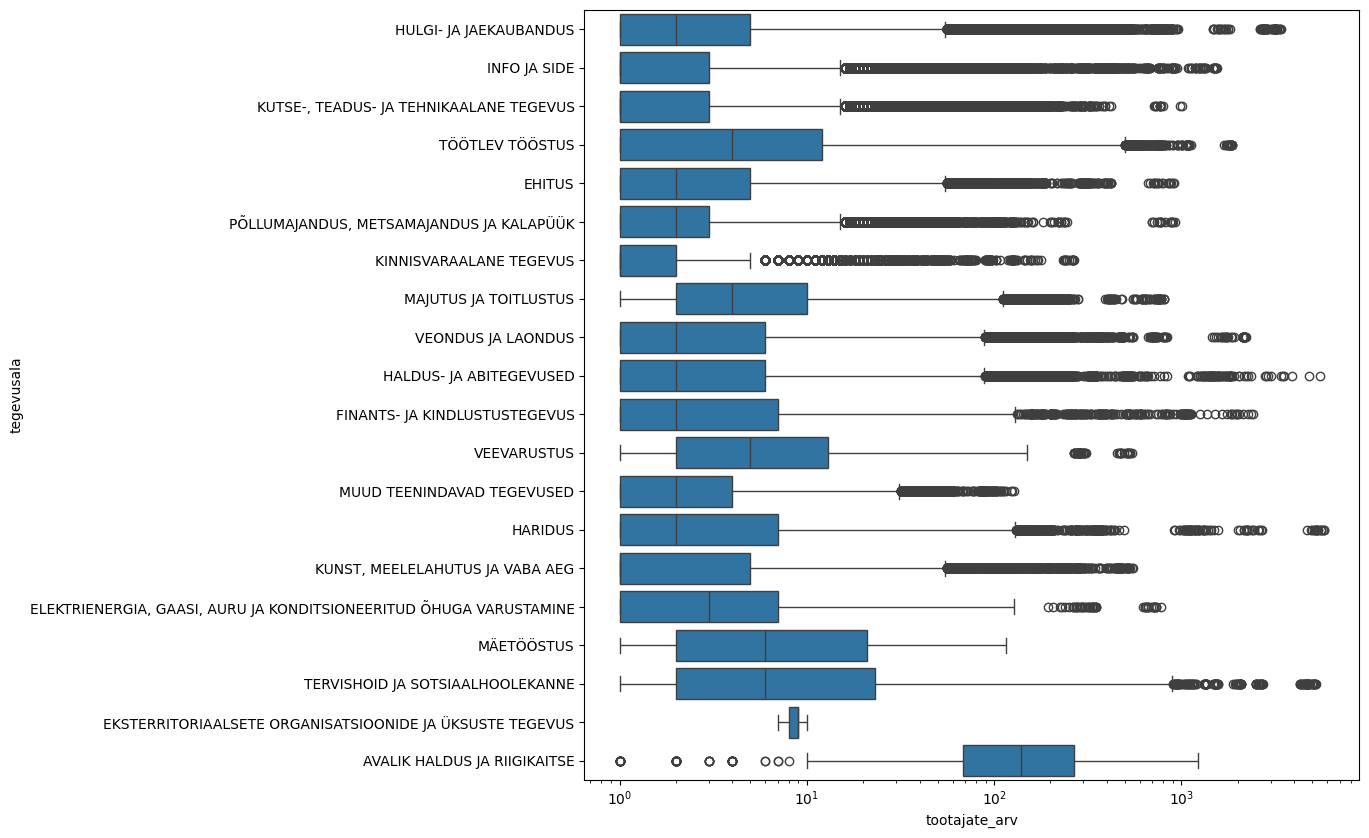

In [68]:
plt.figure(1, figsize=(10, 10)) 
sns.boxplot(data, y="tegevusala", x= "tootajate_arv", log_scale=10)

# logaritmilne skaala - tõstab skaala väärtusi astme võrra, et madalamad väärtused oleks nähtavamad

In [69]:
data.to_csv("emta_data.csv", index=False)

## Töötaja ja käibe suhe

In [70]:
data

,registrikood,nimi,liik,maakond,kov,tegevusala,aasta,kvartal,riiklikud_maksud,toojoumaksud,kaive,tootajate_arv
0,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,1,1723565,1259900,34309154,254
1,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,2,2038192,1229742,30413704,243
2,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,3,2141341,1213643,23282177,244
3,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,4,1844403,1131417,21724706,240
4,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2026,1,1561762,1088007,19993085,236
...,...,...,...,...,...,...,...,...,...,...,...,...
943929,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2023,4,22804,23491,47353,4
943930,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,1,31928,33059,99940,4
943931,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,2,25677,26511,5551,4
943932,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,3,27572,28496,0,4


<Axes: xlabel='tootajate_arv', ylabel='kaive'>

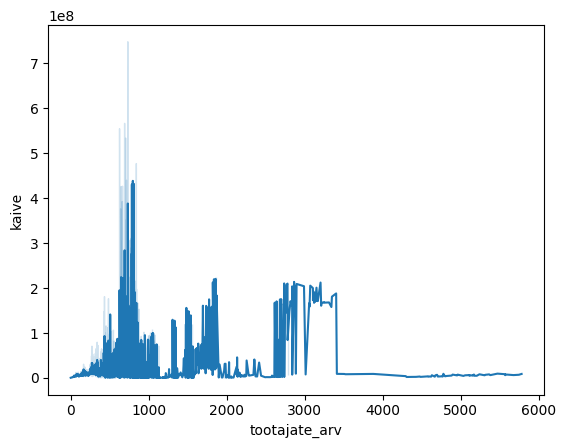

In [71]:
sns.lineplot(data, x="tootajate_arv", y="kaive") 

<Axes: xlabel='tootajate_arv', ylabel='kaive'>

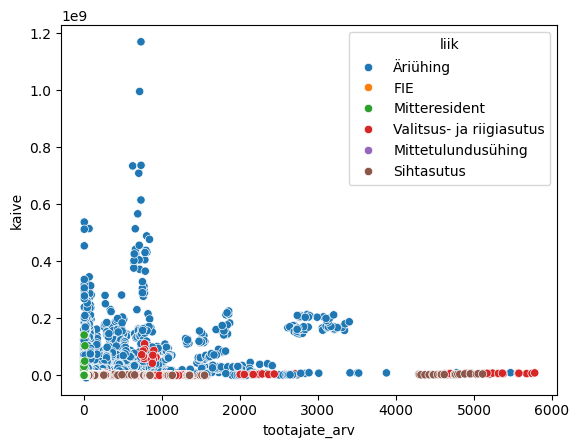

In [74]:
sns.scatterplot(data, x="tootajate_arv", y="kaive", hue="liik") 

In [86]:
# keskmine käive ettevõtte põhiselt ühes kuus

duckdb.sql(f""" 
    SELECT nimi, avg(ROUND(kaive / 3)) ::int AS avg_kaive_kuus
    FROM data
    GROUP BY nimi
    ORDER BY avg(kaive) DESC 
    LIMIT 20
""")

┌───────────────────────┬────────────────┐
│         nimi          │ avg_kaive_kuus │
│        varchar        │     int32      │
├───────────────────────┼────────────────┤
│ EESTI ENERGIA AS      │      191064034 │
│ BOLT OPERATIONS OÜ    │      117072399 │
│ ORLEN EESTI OÜ        │      107338365 │
│ AS ELENGER GRUPP      │       85115652 │
│ TOYOTA BALTIC AS      │       73011311 │
│ MAXIMA EESTI OÜ       │       67236399 │
│ ELERING AS            │       58805571 │
│ MAGNUM MEDICAL OÜ     │       57950210 │
│ ERICSSON EESTI AS     │       57729938 │
│ AS ALEXELA            │       57648332 │
│ SELVER AS             │       55864439 │
│ RIMI EESTI FOOD AS    │       54000532 │
│ OLEREX, AS            │       53635772 │
│ SWEDBANK LIISING AS   │       48715315 │
│ COOP EESTI KESKÜHISTU │       48377296 │
│ TELIA EESTI AS        │       41375611 │
│ AKTSIASELTS AUTO 100  │       37997476 │
│ TALLINK GRUPP, AS     │       36102104 │
│ KIRDE VARAD AS        │       35976218 │
│ BALTIC AG

In [100]:

avg_revenue = duckdb.sql(f""" 
    SELECT 
        nimi, 
        avg(ROUND(kaive / 3)) ::int AS avg_kaive_kuus,
        avg(ROUND(tootajate_arv)) AS tootajate_arv,
        liik
    FROM data
    GROUP BY nimi, liik
    ORDER BY avg_kaive_kuus DESC 
    LIMIT 20
""").df()

avg_revenue

,nimi,avg_kaive_kuus,tootajate_arv,liik
0,EESTI ENERGIA AS,191064034,684.529412,Äriühing
1,BOLT OPERATIONS OÜ,117072399,773.000000,Äriühing
2,ORLEN EESTI OÜ,107338365,7.000000,Äriühing
3,AS ELENGER GRUPP,85115652,79.882353,Äriühing
4,TOYOTA BALTIC AS,73011311,42.529412,Äriühing
5,MAXIMA EESTI OÜ,67236399,3001.705882,Äriühing
6,ELERING AS,58805571,305.470588,Äriühing
7,MAGNUM MEDICAL OÜ,57950210,27.647059,Äriühing
8,ERICSSON EESTI AS,57729938,1805.294118,Äriühing
9,AS ALEXELA,57648332,478.882353,Äriühing


In [109]:
avg_revenue = duckdb.sql(f""" 
    SELECT 
        nimi, 
        avg(ROUND(kaive / 3))::int AS avg_kaive_kuus,
        avg(ROUND(tootajate_arv))::int AS tootajate_arv,
        any_value(liik) AS liik
    FROM data
    GROUP BY nimi
    ORDER BY avg_kaive_kuus DESC 
""").df()

avg_revenue

,nimi,avg_kaive_kuus,tootajate_arv,liik
0,EESTI ENERGIA AS,191064034,685,Äriühing
1,BOLT OPERATIONS OÜ,117072399,773,Äriühing
2,ORLEN EESTI OÜ,107338365,7,Äriühing
3,AS ELENGER GRUPP,85115652,80,Äriühing
4,TOYOTA BALTIC AS,73011311,43,Äriühing
...,...,...,...,...
80884,SMALLMIX OÜ,-5273,2,Äriühing
80885,KE KONSULT OÜ,-7337,2,Äriühing
80886,24/7 KAUBANDUS OÜ,-15756,4,Äriühing
80887,PROFI LOGISTIC OÜ,-15985,1,Äriühing


<Axes: xlabel='tootajate_arv', ylabel='avg_kaive_kuus'>

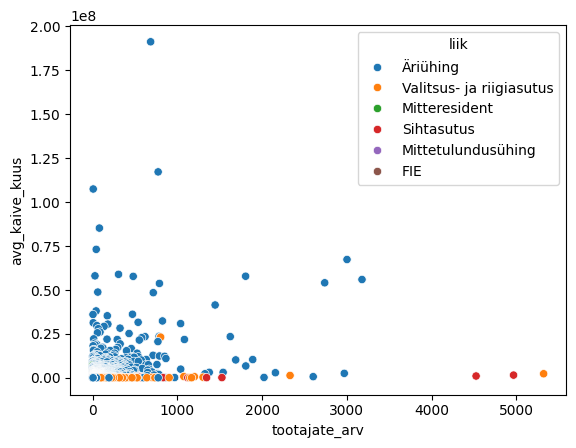

In [108]:
sns.scatterplot(avg_revenue, x="tootajate_arv", y="avg_kaive_kuus", hue="liik") 